<a href="https://colab.research.google.com/github/merajali384022/GDGC-ML-/blob/main/High_Medical_Cost_Predictor(.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor,  RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, confusion_matrix,classification_report


In [75]:
url="https://huggingface.co/datasets/rahulvyasm/medical_insurance_data/resolve/main/medical_insurance.csv"
df=pd.read_csv(url)

In [6]:
print(f'shape of data is {df.shape}')

shape of data is (2772, 7)


In [7]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
print(f"first 10 row of data is:")
print('\n')
df.head(10)

first 10 row of data is:




,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [15]:
print(f"Dataset info")
print('\n')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [16]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [18]:
print("missing value:")
print('\n')
df.isnull().sum()

missing value:




,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'charges'}>]], dtype=object)

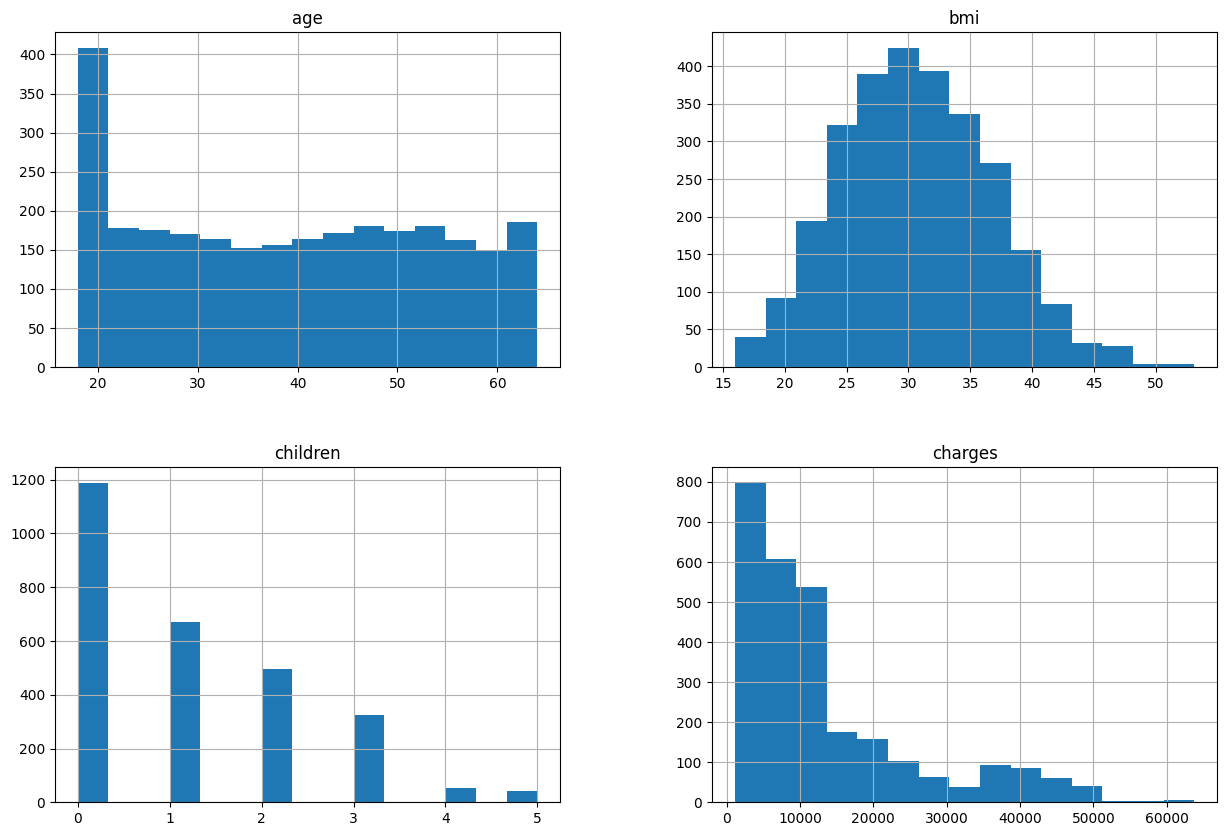

In [23]:
df.select_dtypes(include=[np.number]).hist(bins=15,figsize=(15,10))


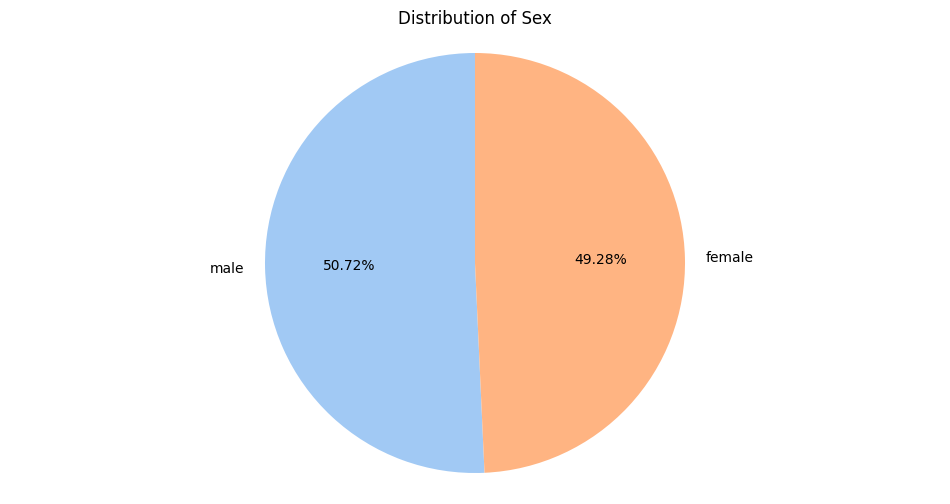

In [55]:
plt.figure(figsize=(10, 6))


sex_counts = df['sex'].value_counts()
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.2f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Sex')
plt.axis('equal')

plt.show()

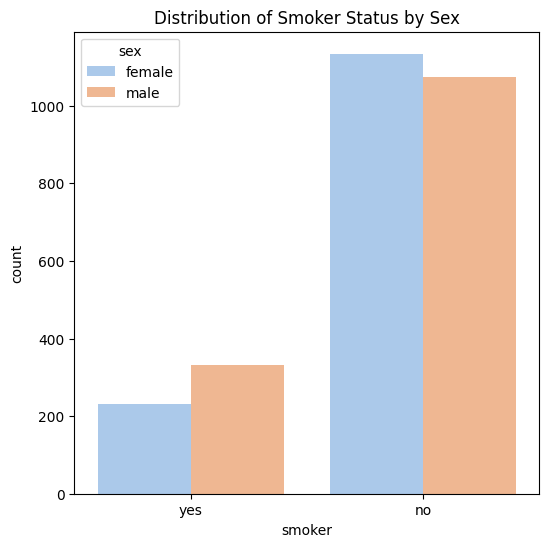

In [57]:
plt.figure(figsize=(6, 6))
sns.countplot(data=df, x='smoker', hue='sex', palette='pastel')
plt.title('Distribution of Smoker Status by Sex')
plt.show()

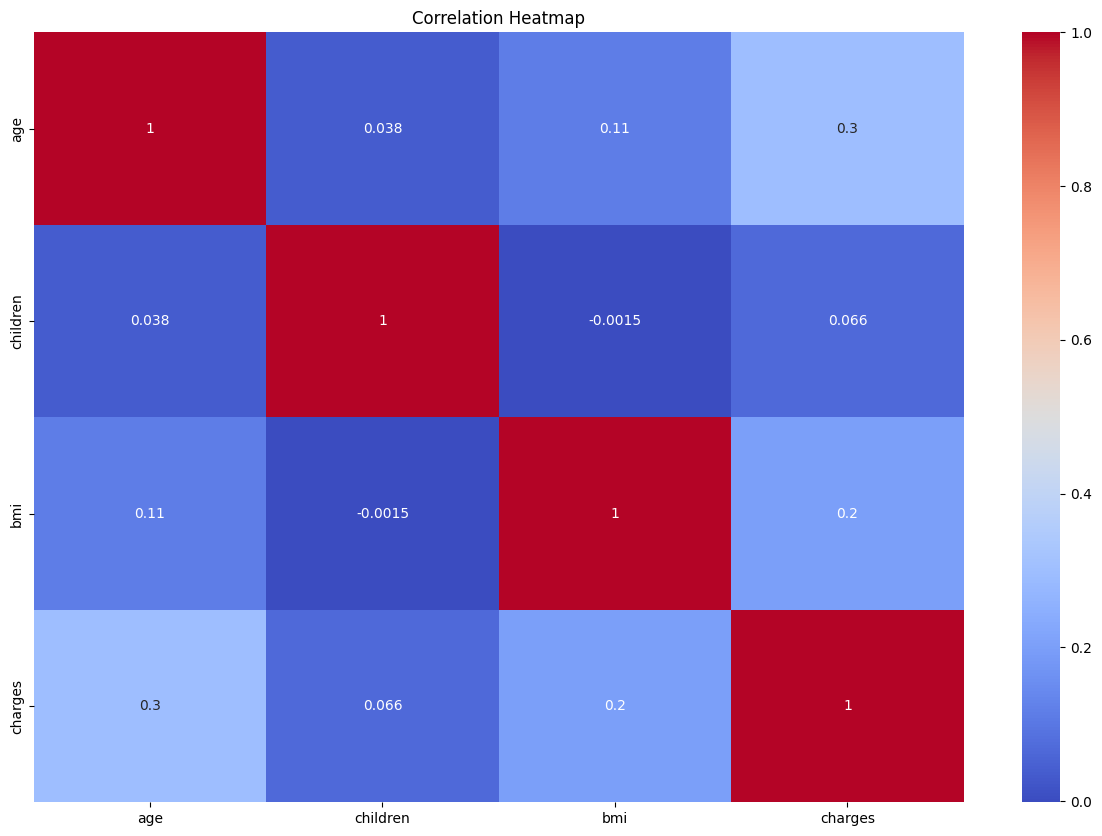

In [58]:
numeric_cols=['age','children','bmi','charges']
plt.figure(figsize=(15,10))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [77]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

In [78]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [69]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [70]:
if 'region' in df.columns:
    df = pd.get_dummies(df, columns=['region'], prefix=['region'])


In [79]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [87]:
print("Original 'region' column no longer exists after one-hot encoding.")
print("Here are the new region-related columns:")
print(df.filter(like='region_').columns.tolist())

Original 'region' column no longer exists after one-hot encoding.
Here are the new region-related columns:
['region_northwest', 'region_southeast', 'region_southwest']


In [85]:
if 'region' in df.columns:
  df=pd.get_dummies(df,columns=['region'],drop_first=True)
else:
    print("column not found")

column not found


In [88]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [89]:
x=df.drop('charges',axis=1)
y=df['charges']

In [90]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [91]:
print(f"shape of X_train is {X_train.shape}")
print(f"shape of X_test is {X_test.shape}")

shape of X_train is (2217, 8)
shape of X_test is (555, 8)


In [92]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [93]:
y_pred=lr.predict(X_test)

In [94]:
rmse_lr=np.sqrt(mean_squared_error(y_test,y_pred))
r2_lr=r2_score(y_test,y_pred)

In [108]:
print("Linear Regression Metrics:")
print(f"Root Mean Squared Error (RMSE): ${rmse_lr:}")
print(f"R-squared (R2) Score: {r2_lr:.3f}")

Linear Regression Metrics:
Root Mean Squared Error (RMSE): $6319.271678607549
R-squared (R2) Score: 0.740


In [97]:
rf_regressor=RandomForestRegressor(n_estimators=100,random_state=42)
rf_regressor.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [98]:
y_pred=lr.predict(X_test)

In [99]:
rmse_lr=np.sqrt(mean_squared_error(y_test,y_pred))
r2_lr=r2_score(y_test,y_pred)

In [105]:
print("Linear Regression Metrics:")
print(f"Root Mean Squared Error (RMSE): ${rmse_lr:.0f}")
print(f"R-squared (R2) Score: {r2_lr:.3f}")

Linear Regression Metrics:
Root Mean Squared Error (RMSE): $6319
R-squared (R2) Score: 0.740


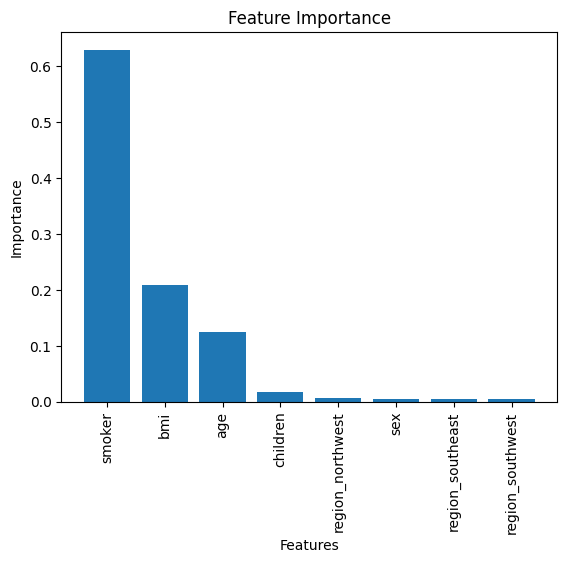

In [116]:
importances = pd.DataFrame(rf_regressor.feature_importances_, index=x.columns, columns=['Importance'])
importances = importances.sort_values(by='Importance', ascending=False)

plt.bar(importances.index, importances['Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()

In [117]:
import joblib
joblib.dump(rf_regressor,'model.pkl')

fearture_columns=x.columns
joblib.dump(fearture_columns,'columns.pkl')
print("saved successfully!!!")

saved successfully!!!


In [118]:
!pip install gradio

In [124]:
import gradio as gr
import pandas as pd
import joblib

# Load the model and feature columns
model = joblib.load("model.pkl")
feature_columns = joblib.load("columns.pkl")

def predict_insurance_charges(age, sex, bmi, children, smoker, region):
    # Prepare input data matching the training data structure
    input_data_dict = {
        'age': age,
        'sex': 1 if sex == "Male" else 0,
        'bmi': bmi,
        'children': children,
        'smoker': 1 if smoker == "Yes" else 0,
        'region_northwest': 0,
        'region_southeast': 0,
        'region_southwest': 0
    }

    # Set the appropriate region column to 1
    if region == "Northwest":
        input_data_dict['region_northwest'] = 1
    elif region == "Southeast":
        input_data_dict['region_southeast'] = 1
    elif region == "Southwest":
        input_data_dict['region_southwest'] = 1
    # If region is "Northeast", all region_ columns remain 0, which is correct for dummy encoding with drop_first=True (implicitly handled here).

    # Create a DataFrame with the correct column order as during training
    input_df = pd.DataFrame([input_data_dict], columns=feature_columns)

    # Predict the charge
    predicted_charge = model.predict(input_df)[0]

    return f"${predicted_charge:,.2f}"

# Gradio Interface
with gr.Blocks(
    theme=gr.themes.Soft(),
    title="Medical Insurance Charges Predictor"
) as demo:
    gr.Markdown(
        """
        # 🏥 AI Medical Insurance Charges Predictor

        Predict the *medical insurance charges* for a patient.
        """
    )

    with gr.Row():
        with gr.Column():
            age = gr.Slider(
                minimum=18, maximum=100, value=25, step=1, label="Age"
            )
            sex = gr.Radio(
                choices=["Male", "Female"], value="Male", label="Gender"
            )
            bmi = gr.Number(
                value=25.0, label="BMI"
            )
            children = gr.Slider(
                minimum=0, maximum=5, value=0, step=1, label="Children"
            )
            smoker = gr.Radio(
                choices=["Yes", "No"], value="No", label="Smoker"
            )
            region = gr.Dropdown(
                choices=["Northeast", "Northwest", "Southeast", "Southwest"],
                value="Northeast", label="Region"
            )
            predict_btn = gr.Button(
                "🔍 Predict Charges", variant="primary"
            )
        with gr.Column():
            output_charge = gr.Textbox(
                label="Predicted Medical Charges"
            )

    predict_btn.click(
        predict_insurance_charges,
        inputs=[age, sex, bmi, children, smoker, region],
        outputs=output_charge
    )

demo.launch(share=True)

/tmp/ipykernel_2719/2016131013.py:40: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7132a4868a5c06076b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
